In [69]:
import pandas as pd
import torch 
from torch import nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

data = pd.read_csv('housing.csv')

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [71]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [72]:
data.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [ ]:
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())
data = pd.get_dummies(data ,columns= ['ocean_proximity'], dtype=float)

In [ ]:
targets = data['median_house_value']
inputs = data.drop(columns=['median_house_value'])

In [75]:
# X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=42)

# scaler = StandardScaler()

# # 2 & 3. Fit ONLY on training data, then transform training data
# X_train_scaled = scaler.fit_transform(X_train)

# # 4. Transform test data using the parameters learned from the training data
# X_test_scaled = scaler.transform(X_test)

In [76]:
inputs_mean = inputs.mean()
inputs_std = inputs.std()

inputs_normalized = (inputs - inputs_mean) / inputs_std


targets_mean = targets.mean()
targets_std = targets.std()

targets_normalized = (targets - targets_mean) / targets_std

# X = torch.tensor(X_train_scaled, dtype=torch.float32)
X = torch.tensor(inputs_normalized.values, dtype=torch.float32)
y = torch.tensor(targets_normalized.values, dtype=torch.float32)

In [77]:
train_ds = TensorDataset(X, y)

batch_size = 32

train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [78]:
model = nn.Linear(X.shape[1], 1)
loss_fn = F.mse_loss
opt = torch.optim.SGD(model.parameters(), lr= 1e-5)

In [79]:
train_losses = []

def fit(epochs, model, loss_fn, opt):

    for epoch in range(epochs):

        epoch_loss = 0.0

        for xb, yb in train_dl:

            pred = model(xb).squeeze(1)

            loss = loss_fn(pred, yb)

            loss.backward()

            opt.step()
            opt.zero_grad()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_dl)
        train_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(
                'Epoch [{}/{}], Loss: {:.4f}'
                .format(epoch + 1, epochs, avg_loss)
            )

In [80]:
fit(100, model, loss_fn, opt)

Epoch [10/100], Loss: 1.0022
Epoch [20/100], Loss: 0.8224
Epoch [30/100], Loss: 0.7067
Epoch [40/100], Loss: 0.6269
Epoch [50/100], Loss: 0.5694
Epoch [60/100], Loss: 0.5271
Epoch [70/100], Loss: 0.4953
Epoch [80/100], Loss: 0.4713
Epoch [90/100], Loss: 0.4530
Epoch [100/100], Loss: 0.4389


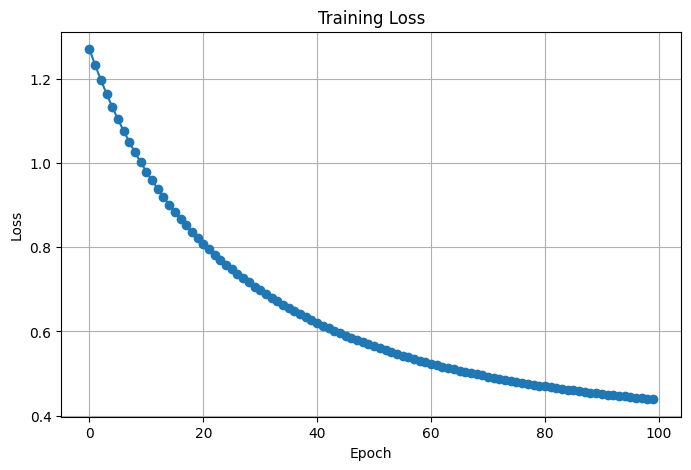

In [81]:

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [82]:
def predict(x):
    x_normalized = (x - inputs_mean) / inputs_std
    # x_normalized = StandardScaler(X_test)
    tensor = torch.tensor(x_normalized.values, dtype=torch.float32)

    with torch.no_grad():
        pred_normalized = model(tensor).squeeze(1)

    return (pred_normalized * targets_std) + targets_mean
    # return pred_normalized

model.eval()
pred = predict(inputs.iloc[:5])
actuals = targets.iloc[:5].values

for p,a in zip(pred.tolist(), actuals):
    print(f'Pred  {p:>10,.0f}$ |  Actual:  {a:>10,.0f}$')



Pred     375,710$ |  Actual:     452,600$
Pred     381,158$ |  Actual:     358,500$
Pred     364,644$ |  Actual:     352,100$
Pred     321,501$ |  Actual:     341,300$
Pred     275,470$ |  Actual:     342,200$
